In [1]:
!pip install neo4j
!pip install networkx pyvis

In [2]:
from neo4j import GraphDatabase

print("Neo4j driver imported successfully ✅")

Neo4j driver imported successfully ✅


✅ Loaded 157 triplets


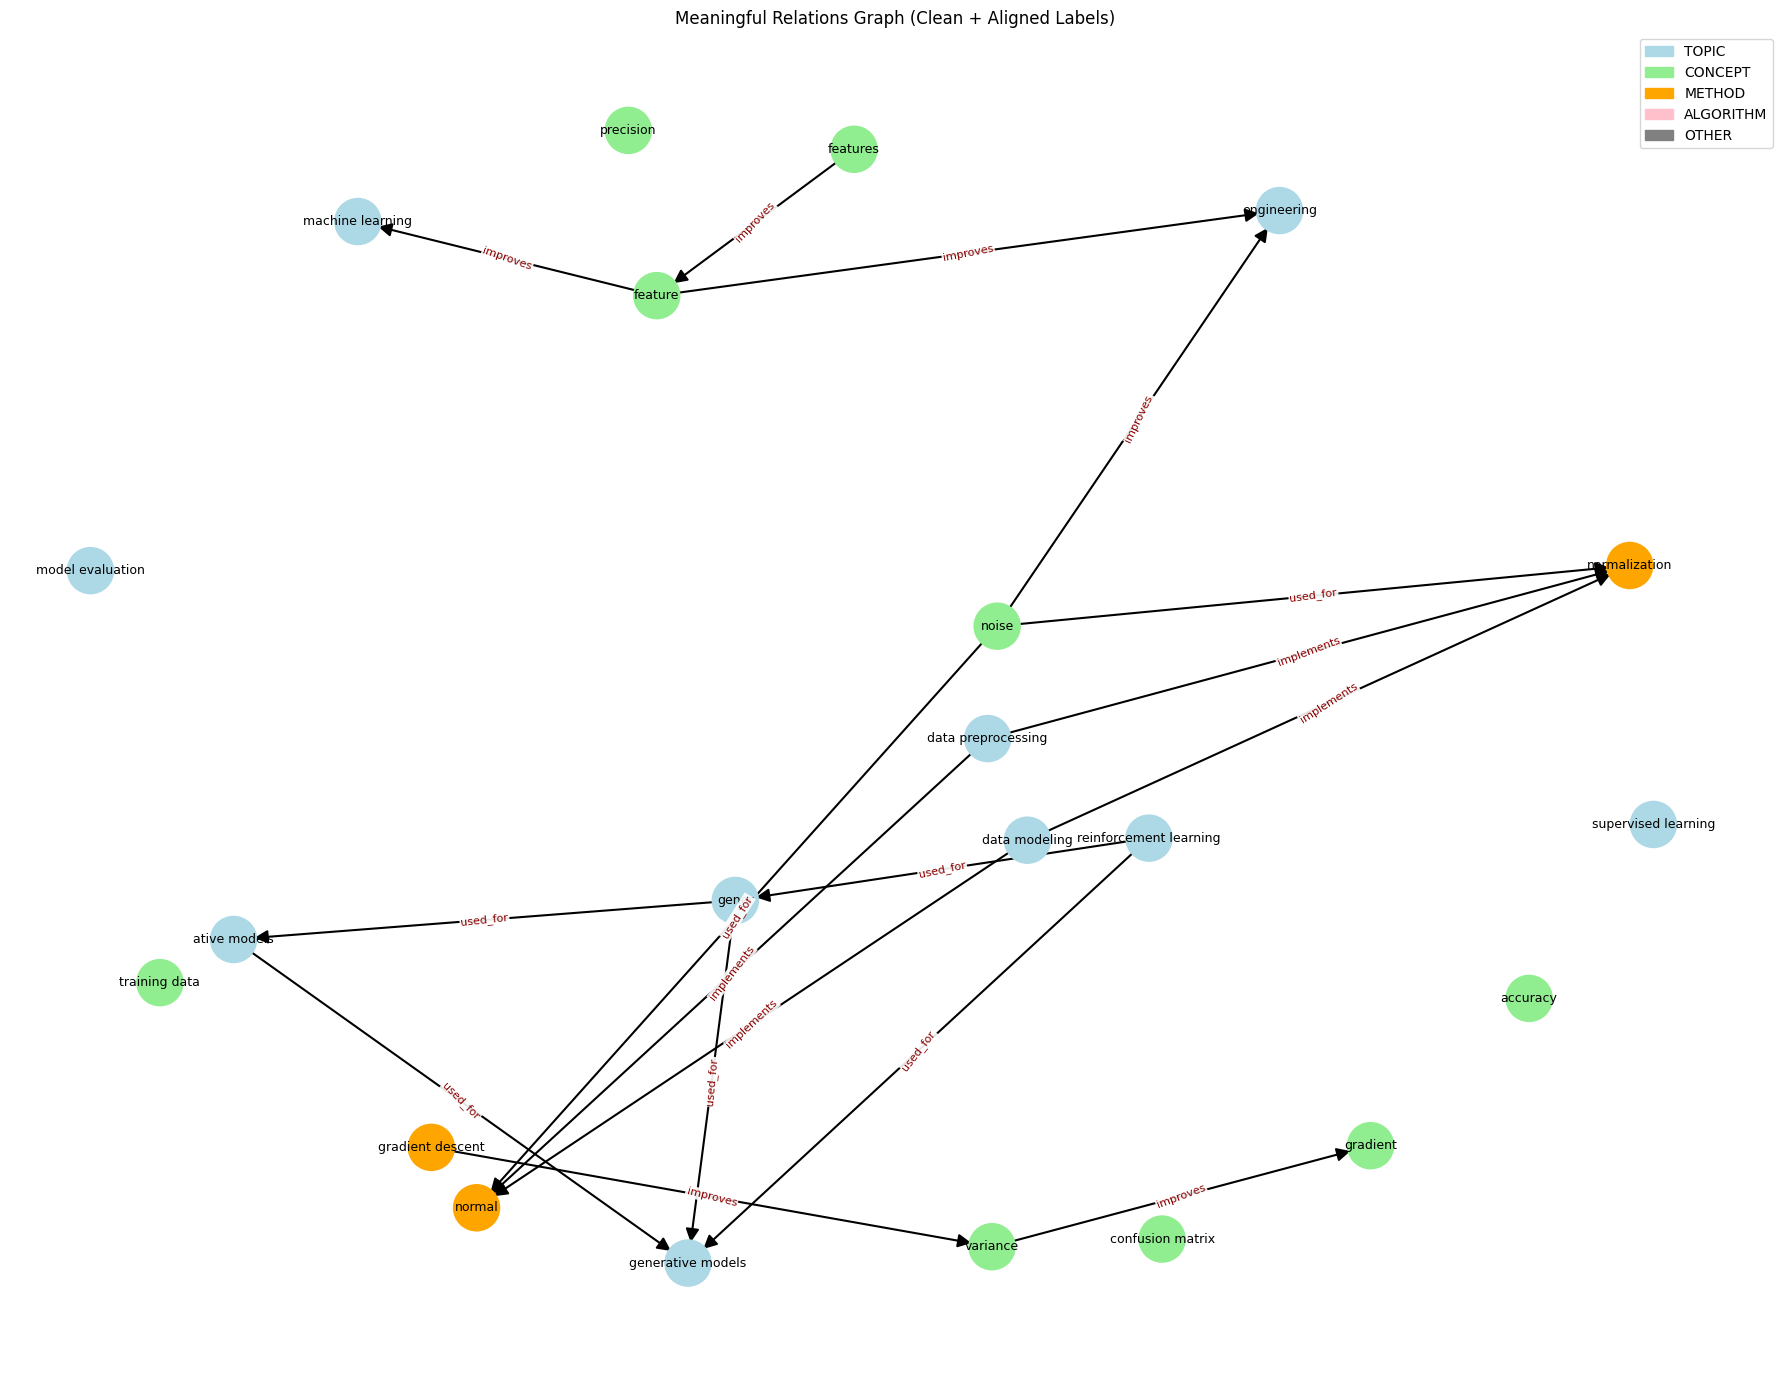

In [6]:
# =========================================
# 1️⃣ IMPORTS
# =========================================
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import random

# =========================================
# 2️⃣ LOAD TRIPLETS
# =========================================
with open("/content/final_triplets_level2.json") as f:
    triplets = json.load(f)

print(f"✅ Loaded {len(triplets)} triplets")

# =========================================
# 3️⃣ MAIN GRAPH (NO part_of)
# =========================================
main_triplets = [t for t in triplets if t["relation"] != "part_of"]

if len(main_triplets) < 10:
    main_triplets = triplets[:30]

MAX_EDGES = 25
main_triplets = main_triplets[:MAX_EDGES]

# =========================================
# 4️⃣ BUILD GRAPH
# =========================================
G_main = nx.DiGraph()

for t in main_triplets:
    G_main.add_node(t["entity1"], label=t["entity1_type"])
    G_main.add_node(t["entity2"], label=t["entity2_type"])
    G_main.add_edge(t["entity1"], t["entity2"], relation=t["relation"])

# =========================================
# 5️⃣ REMOVE HUB NODES (OPTIONAL)
# =========================================
for node in list(G_main.nodes()):
    if G_main.degree(node) > 6:
        G_main.remove_node(node)

# =========================================
# 6️⃣ COLOR MAP
# =========================================
color_map = {
    "TOPIC": "lightblue",
    "CONCEPT": "lightgreen",
    "METHOD": "orange",
    "ALGORITHM": "pink",
    "OTHER": "gray"
}

node_colors = [
    color_map.get(G_main.nodes[n].get("label", "OTHER"), "gray")
    for n in G_main.nodes()
]

# =========================================
# 7️⃣ LAYOUT
# =========================================
pos = nx.spring_layout(G_main, k=2.5, iterations=150, seed=42)

# =========================================
# 8️⃣ DRAW GRAPH
# =========================================
plt.figure(figsize=(18, 14))

nx.draw_networkx_nodes(
    G_main, pos,
    node_color=node_colors,
    node_size=1100
)

nx.draw_networkx_edges(
    G_main,
    pos,
    edgelist=G_main.edges(),
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    width=1.5,
    edge_color="black",
    connectionstyle="arc3,rad=0.0",
    min_source_margin=15,
    min_target_margin=15
)

nx.draw_networkx_labels(
    G_main, pos,
    font_size=9
)

# =========================================
# 🔥 EDGE LABELS EXACTLY ON LINES (NO FLOATING)
# =========================================
for (u, v, d) in G_main.edges(data=True):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    # ✅ EXACT midpoint (ONLY correct position)
    mx = (x1 + x2) / 2
    my = (y1 + y2) / 2

    # ✅ edge angle for alignment
    angle = math.degrees(math.atan2(y2 - y1, x2 - x1))

    # keep text upright (important for readability)
    if angle > 90 or angle < -90:
        angle += 180

    plt.text(
        mx,
        my,
        d["relation"],
        fontsize=8,
        color="darkred",
        ha='center',
        va='center',
        rotation=angle,
        rotation_mode='anchor',
        bbox=dict(
            facecolor='white',
            alpha=0.9,
            edgecolor='none',
            pad=0.8
        )
    )

# =========================================
# 9️⃣ LEGEND
# =========================================
legend_handles = [
    mpatches.Patch(color=color_map[k], label=k)
    for k in color_map
]

plt.legend(handles=legend_handles, loc="best")

# =========================================
# 🔟 FINAL
# =========================================
plt.title("Meaningful Relations Graph (Clean + Aligned Labels)")
plt.axis("off")
plt.tight_layout()
plt.show()